### Preprocessing data

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import json

# Preprocess the data
initial_data = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
initial_data = initial_data[~initial_data['Protein_FASTA'].str.contains('X')] # remove complexes with ambiguous char in FASTA string
toDrop = ['4yx4', '1laf', '4buq', '1k22', '1hmt', '1utn', '4rux', '1bty']
initial_data = initial_data[~initial_data['PDB_Code'].isin(toDrop)]
initial_data = initial_data.reset_index() # final dataset

# Load protein and ligand embeddings data
# protein_t6 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/protein_embeddings_t6.npy")
# ligand_t6 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/ligand_embeddings_t6.npy")
protein_t12 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/protein_embeddings_t12.npy")
ligand_t12 = np.load("/dcs/22/u2243582/cs310/seq_embeddings/ligand_embeddings_t12.npy")

/dcs/22/u2243582/.local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
# Single array of embeddings data
embeddings = np.concatenate((protein_t12, ligand_t12), axis=1) # (5059, 864)

# Scale features and apply PCA before we split into folds!
scaler = StandardScaler()
scaler.fit(embeddings)
embeddings_scaled = scaler.transform(embeddings)
X = pd.DataFrame(embeddings_scaled, index=initial_data.index) # convert to DataFrame

pca = PCA(0.85) # keep 85% of the variance of the data
pca.fit(embeddings_scaled)
X_pca = pca.transform(embeddings_scaled)
X = pd.DataFrame(X_pca, index=initial_data.index, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]) # convert back to DataFrame

print("Components:", pca.n_components_ , "Total explained variance:", pca.explained_variance_ratio_.sum())

Components: 65 Total explained variance: 0.85157335


In [3]:
data = X.join(initial_data)
display(data)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC62,PC63,PC64,PC65,index,PDB_Code,Protein_FASTA,Ligand_SMILES,Binding_data,Log_binding
0,-5.707636,-9.313955,4.742897,7.738206,-5.948133,-12.761560,-5.361453,-2.554196,-4.082337,2.908875,...,0.753950,-1.185910,1.065766,0.096639,0,6ugp,HWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSV...,O=C1Nc2c(Cl)cccc2S(=O)(=O)N1,Ki=685.5nM,6.16
1,-5.288695,-7.858925,2.887526,-0.427879,5.947171,-3.214900,-7.169189,1.802743,4.187888,5.041792,...,1.119298,0.403438,0.209644,0.539347,1,4rdn,ENLYFQHMKHGRVFIIKSYSEDDIHRSIKYNIWCSTEHGNKRLDAA...,CNc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Kd=1.2uM,5.92
2,-8.829623,19.201303,10.093707,-7.419285,-3.203775,-0.232176,-2.159177,-3.520984,-3.908530,3.492595,...,1.327627,0.829926,-1.831739,-1.584211,2,4mo4,PRYLGLMSGTSLDGMDIVLIEQGDRTTLLASHYLPMPAGLREDILA...,C[P@@](=O)([O-])O[P@@](=O)([O-])OC[C@H]1O[C@@H...,Kd=0.06mM,4.22
3,-8.467176,-9.196644,-2.844220,-1.655047,-2.238424,1.371800,-4.598311,1.857956,3.944184,-5.405472,...,2.431078,0.928278,-2.512673,-1.026405,3,3s0b,MTIEELKTRLHTEQSVCKTETGIDQQKANDVIEGNIDVEDKKVQLY...,c1ccc(Nc2cccc3ccccc23)cc1,Kd=0.32uM,6.49
4,-7.821224,-11.102284,3.519109,-0.505102,2.511193,4.467752,-3.364132,-0.569330,-6.121096,4.928209,...,-2.285230,1.823197,-1.743173,-0.761504,4,6r1d,ASIFRCRQCGQTISRRDWLLPMGGDHEHVVFNPAGMIFRVWCFSLA...,O=C1C[C@H](NC(=O)OCc2ccccc2)C(=O)N1,Ki=4uM,5.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5054,23.039593,6.915682,-3.664122,-2.330799,-4.044440,-3.221871,-2.861252,-0.687056,-2.253632,4.939064,...,-0.619700,-0.644370,0.650784,0.432207,5244,6p3t,VTLCSPTEDDWPGMFLLAAASFTDFIGPESATAWRTLVPTDGAVVV...,CN(c1ccc2ccccc2c1)S(=O)(=O)c1ccc2[nH]c(=O)c(=O...,Ki=0.048uM,7.32
5055,-6.465629,-9.765017,3.442423,4.728262,-1.583070,-5.719411,8.120670,11.612959,2.267360,-3.633904,...,-1.194786,-3.065439,-0.457095,-0.252605,5245,1tx7,IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGI...,C[P@@](=O)([O-])c1ccc(C(N)=[NH2+])cc1,Ki=25uM,4.60
5056,20.151129,9.270433,21.072338,-10.288429,-6.621681,1.154924,2.571498,0.846374,-0.650135,-1.567289,...,0.617966,-1.497795,-3.185125,-1.140795,5246,3ta1,MKMVVAVIRPEKLECVKKALEERGFVGMTVTEVKGRGEQKGIRLQF...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@@](=O)([O-])O...,Kd=568uM,3.25
5057,-7.896084,-7.567359,4.859779,2.797632,2.459224,6.084409,-0.755946,-5.263092,-3.916721,5.105237,...,-3.177269,-1.670812,0.069729,0.537529,5247,6r0v,VLAPGASIFRCRQCGQTISRRDWLLPMGGDHEHVVFNPAGMIFRVW...,O=C1C[C@H](NC(=O)c2cc([N+](=O)[O-])ccc2C(=O)[O...,Ki=11uM,4.96


### Making non-redundant cross-validation folds from the similarity clusters

In [4]:
with open("/dcs/22/u2243582/cs310/nrkf_physicochem_feat/clustered_proteins.json", "r") as json_file:
    cluster_dict = json.load(json_file)
print(len(cluster_dict))

cluster_assignment_dict = {}
for cluster_ind in cluster_dict:
    for pdb in cluster_dict[cluster_ind]:
        cluster_assignment_dict[pdb] = cluster_ind
        
identifiers = list(cluster_assignment_dict.keys())

1192


In [ ]:
# ! Using code from https://github.com/foxtrotmike/BioTools/blob/main/NRKFold.py
def NRKFold(E,pc,K = 5, shuffle=True):
    """
    Generate non-redundant K-folds for a dataset where each example involves an object 
    that belongs to a certain cluster. This function ensures that no two folds contain 
    objects from the same cluster and aims to distribute the number of examples 
    approximately equally across all folds.

    This is particularly useful in scenarios where data points can naturally group into 
    clusters (e.g., proteins in bioinformatics), and it is important to avoid having 
    similar examples in both the training and validation sets of a particular fold.

    Parameters
    ----------
    E : List
        A list containing identifiers of objects involved in each example.
    pc : Dictionary
        A dictionary mapping each object to its cluster assignment.
    K : Integer, optional
        The number of folds to create. Default is 5.
    shuffle : Boolean, optional
        Determines whether to shuffle the cluster to fold assignments in different runs.
        Default is True.

    Returns
    -------
    List of lists
        A list where each sublist contains the indices of examples in `objects` that belong to a particular fold.

    Example
    -------
    >>> objects = ['obj1', 'obj2', 'obj3', 'obj4', 'obj5', 'obj6', 'obj1']
    >>> clusters = {'obj1': 1, 'obj2': 2, 'obj3': 1, 'obj4': 2, 'obj5': 3, 'obj6': 3}
    >>> folds = NRKFold(objects, clusters, K=2, shuffle=False)
    >>> print(folds)
    Output might be: [[0, 2, 6], [1, 3, 4, 5]]
    Here, objects 'obj1', 'obj3', and 'obj1' (indices 0, 2, 6) are in one fold, 
    and the rest are in another fold, ensuring no fold has objects from the same cluster.
    """
    e = [pc[str(x)] for x in E] #cluster indices of all proteins in the examples
    c2idx={} #indices of examples of each cluster in e
    for i,x in enumerate(e):
        try: 
            c2idx[x].append(i)
        except:
            c2idx[x]=[i]    
    ce = dict([(c,len(c2idx[c])) for c in c2idx]) #counts of examples of different clusters    
    cF = [0]*K; #counts of examples in each fold
    CF = [[] for _ in range(K)]; #clusters in each fold
    F = [[] for _ in range(K)];#indices of examples in each fold
    keys = list(ce.keys())
    if shuffle:
        random.shuffle(keys)
    for k in keys:
        v = ce[k]
        idx = np.argmin(cF)
        cF[idx]+=v
        CF[idx].append(k) #add cluster to fold
        F[idx].extend(c2idx[k])
    return F

In [6]:
folds = NRKFold(identifiers, cluster_assignment_dict)

In [7]:
final_folds = []
for fold in folds:
    temp_fold = []
    for obj in fold:
        pdb = identifiers[obj]
        data_ind = data.index[data['PDB_Code'] == pdb].item()
        temp_fold.append(data_ind)
    final_folds.append(temp_fold)
    
# The final NRKfolds:
splits = [
    {
        "train_ix": final_folds[0] + final_folds[1] + final_folds[2] + final_folds[3],
        "test_ix": final_folds[4]
    },
    {
        "train_ix": final_folds[0] + final_folds[1] + final_folds[2] + final_folds[4],
        "test_ix": final_folds[3]
    },
    {
       "train_ix": final_folds[0] + final_folds[1] + final_folds[4] + final_folds[3],
        "test_ix": final_folds[2]
    },
    {
        "train_ix": final_folds[0] + final_folds[4] + final_folds[2] + final_folds[3],
        "test_ix": final_folds[1]
    },
    {
        "train_ix": final_folds[4] + final_folds[1] + final_folds[2] + final_folds[3],
        "test_ix": final_folds[0]
    }
]

### Random Forest

In [8]:
# Use modal hyperparameters from baseline nested cv

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []

for fold in splits:

    train_ix = np.array(fold["train_ix"])
    test_ix = np.array(fold["test_ix"])
    
    X_train = data.loc[train_ix, 'PC1':'PC65']
    X_test = data.loc[test_ix, 'PC1':'PC65']
    y_train = data.loc[train_ix, 'Log_binding']
    y_test = data.loc[test_ix, 'Log_binding']
    
    randForest = RandomForestRegressor(n_estimators=300, min_samples_split=10, min_samples_leaf=5, max_features=1.0, max_depth=90)
    randForest.fit(X_train,y_train)
    randForestPred = randForest.predict(X_test)
    
    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, randForestPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, randForestPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, randForestPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - randForestPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, randForestPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

Pearson Correlation: Mean = 0.47950599672341615, Std = 0.08228257120777654
Pearson P-value: Mean = 2.560106384003154e-29, Std = 5.120212768006307e-29
Spearman Correlation: Mean = 0.4714582185277503, Std = 0.08783000921336631
Spearman P-value: Mean = 2.4381153874586653e-26, Std = 4.87623077491733e-26
Mean Absolute Error: Mean = 1.3897955489913971, Std = 0.1823544051888497
Variance of Errors: Mean = 2.8741811801802233, Std = 0.5620823446858831
R2: Mean = 0.19466308165054616, Std = 0.07601995799930285


### SVR

In [9]:
# Use modal hyperparameters from baseline nested cv:
# ...

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []

for fold in splits:

    train_ix = np.array(fold["train_ix"])
    test_ix = np.array(fold["test_ix"])

    X_train = data.loc[train_ix, 'PC1':'PC65']
    X_test = data.loc[test_ix, 'PC1':'PC65']
    y_train = data.loc[train_ix, 'Log_binding']
    y_test = data.loc[test_ix, 'Log_binding']
    
    svRegressor = SVR(kernel='rbf', gamma='scale', epsilon=0.6, C=8)
    svRegressor.fit(X_train, y_train)
    svRegressorPred = svRegressor.predict(X_test)
    
    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, svRegressorPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, svRegressorPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, svRegressorPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - svRegressorPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, svRegressorPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

Pearson Correlation: Mean = 0.5889757870583217, Std = 0.06083560422250328
Pearson P-value: Mean = 1.1974424089617486e-72, Std = 2.391679265407932e-72
Spearman Correlation: Mean = 0.5872513602429065, Std = 0.07280296313932608
Spearman P-value: Mean = 5.2498256792370285e-70, Std = 7.9879918038549e-70
Mean Absolute Error: Mean = 1.2444432647415706, Std = 0.057494965529314185
Variance of Errors: Mean = 2.4074249457620223, Std = 0.1961893767393154
R2: Mean = 0.3202060731651068, Std = 0.07859553625257798


### XGBoost

In [10]:
# Use modal hyperparameters from baseline nested cv:
# ...

# Store metrics across folds
pearsonCoeffs = []
pearsonPValues = []
spearmanCoeffs = []
spearmanPValues = []
maeScores = []
varianceScores = []
r2Scores = []

for fold in splits:

    train_ix = np.array(fold["train_ix"])
    test_ix = np.array(fold["test_ix"])
    
    X_train = data.loc[train_ix, 'PC1':'PC65']
    X_test = data.loc[test_ix, 'PC1':'PC65']
    y_train = data.loc[train_ix, 'Log_binding']
    y_test = data.loc[test_ix, 'Log_binding']
    
    xgReg = XGBRegressor(subsample=0.5, reg_lambda=10, reg_alpha=1, max_depth=9, learning_rate=0.1, gamma=0, colsample_bytree=1)
    xgReg.fit(X_train, y_train)
    xgPred = xgReg.predict(X_test)
    
    # Pearson Correlation
    pearsonCoef, pearsonP = pearsonr(y_test, xgPred)
    pearsonCoeffs.append(pearsonCoef)
    pearsonPValues.append(pearsonP)
    
    # Spearman Correlation
    spearmanCoef, spearmanP = spearmanr(y_test, xgPred)
    spearmanCoeffs.append(spearmanCoef)
    spearmanPValues.append(spearmanP)
    
    # Mean Absolute Error
    mae = mean_absolute_error(y_test, xgPred)
    maeScores.append(mae)
    
    # Variance of Errors
    variance = np.var(y_test - xgPred)
    varianceScores.append(variance)

    # R2 (Coefficient of Determination)
    r2 = r2_score(y_test, xgPred)
    r2Scores.append(r2)
    
# Calculate mean and standard deviation for each metric
metricsSummary = {
    "Pearson Correlation": (np.mean(pearsonCoeffs), np.std(pearsonCoeffs)),
    "Pearson P-value": (np.mean(pearsonPValues), np.std(pearsonPValues)),
    "Spearman Correlation": (np.mean(spearmanCoeffs), np.std(spearmanCoeffs)),
    "Spearman P-value": (np.mean(spearmanPValues), np.std(spearmanPValues)),
    "Mean Absolute Error": (np.mean(maeScores), np.std(maeScores)),
    "Variance of Errors": (np.mean(varianceScores), np.std(varianceScores)),
    "R2": (np.mean(r2Scores), np.std(r2Scores))
}

# Print metrics summary
for metric, (mean, std) in metricsSummary.items():
    print(f"{metric}: Mean = {mean}, Std = {std}")

Pearson Correlation: Mean = 0.5019066375819771, Std = 0.04111550835002535
Pearson P-value: Mean = 1.901882918276799e-55, Std = 3.79906289335283e-55
Spearman Correlation: Mean = 0.4965720718309842, Std = 0.04829990338512266
Spearman P-value: Mean = 1.6021780798306423e-51, Std = 3.203891962451021e-51
Mean Absolute Error: Mean = 1.3552827028607353, Std = 0.16144504722593267
Variance of Errors: Mean = 2.7788942823517453, Std = 0.4817248080133449
R2: Mean = 0.22251517808932028, Std = 0.0344709909041354


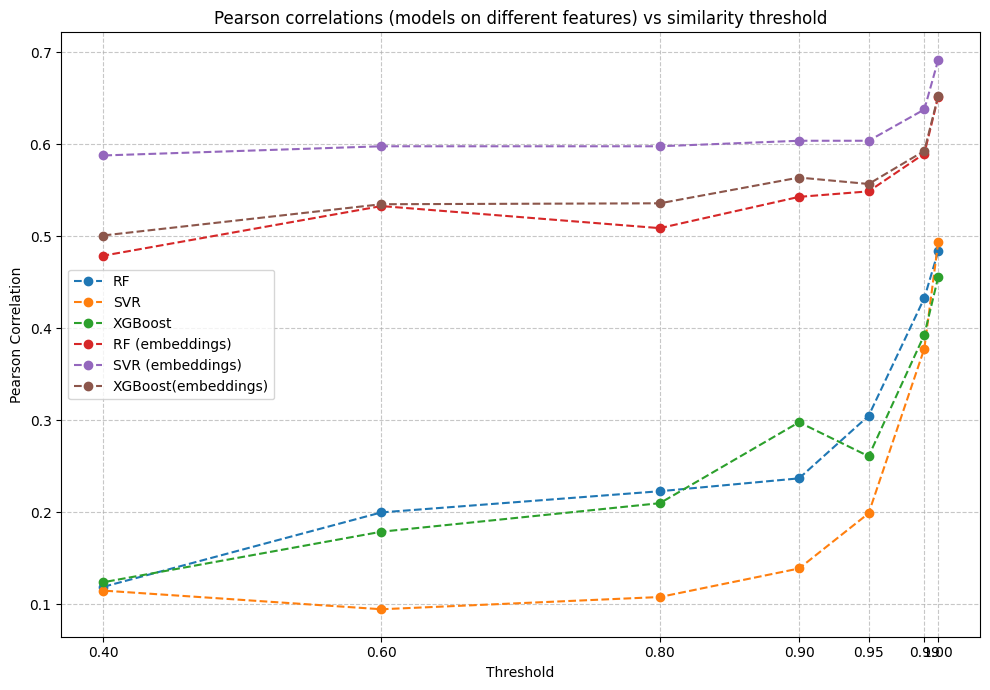

In [14]:
# Compare them all - pearson correlations

thresholds = [1, 0.99, 0.95, 0.90, 0.80, 0.60, 0.40]

rf = [0.484, 0.433, 0.305, 0.237, 0.223, 0.200, 0.119]
svr = [0.494, 0.378, 0.199, 0.139, 0.108, 0.0947, 0.115]
xg = [0.456, 0.393, 0.261, 0.298, 0.21, 0.179, 0.124]

rf_emb = [0.652, 0.59, 0.549, 0.543, 0.509, 0.533, 0.479]
svr_emb = [0.692, 0.638, 0.604, 0.604, 0.598, 0.598, 0.588]
xg_emb = [0.653, 0.593, 0.557, 0.564, 0.536, 0.535, 0.501]

plt.figure(figsize=(10, 7))
plt.errorbar(thresholds, rf, fmt='o--', label='RF', capsize=5)
plt.errorbar(thresholds, svr, fmt='o--', label='SVR', capsize=5)
plt.errorbar(thresholds, xg, fmt='o--', label='XGBoost', capsize=5)
plt.errorbar(thresholds, rf_emb, fmt='o--', label='RF (embeddings)', capsize=5)
plt.errorbar(thresholds, svr_emb, fmt='o--', label='SVR (embeddings)', capsize=5)
plt.errorbar(thresholds, xg_emb, fmt='o--', label='XGBoost(embeddings)', capsize=5)

# Customizing the plot
plt.title('Pearson correlations (models on different features) vs similarity threshold')
plt.xlabel('Threshold')
plt.ylabel('Pearson Correlation')
plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()